Purpose: Investigate results of GO enrichment on maSigPro gene sets.<br>
Author: Anna Pardo<br>
Date initiated: May 4, 2026

In [48]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [2]:
# load results
res = pd.read_csv("./masigpro_TS_DE_bothsg_goenrich_01-May-2026.txt",sep="\t",header="infer")
res.head()

,p.value,GO.term,p.adj,regset,Ontology,Term,Annotated,Significant,Expected,result1,Descr
0,0.000116,GO:0000244,0.010152,YgCAM_TS,BP,spliceosomal tri-snRNP complex assembly,15.0,5.0,0.52,0.00012,spliceosomal tri-snRNP complex assembly
1,0.000027,GO:0000302,0.003352,YgCAM_TS,BP,response to reactive oxygen species,285.0,25.0,9.96,2.7e-05,response to reactive oxygen species
2,0.000006,GO:0000373,0.000972,YgCAM_TS,BP,Group II intron splicing,39.0,9.0,1.36,6.2e-06,Group II intron splicing
3,0.000747,GO:0000387,0.043535,YgCAM_TS,BP,spliceosomal snRNP assembly,32.0,6.0,1.12,0.00075,spliceosomal snRNP assembly
4,0.000303,GO:0000395,0.022467,YgCAM_TS,BP,mRNA 5'-splice site recognition,18.0,5.0,0.63,0.00030,mRNA 5'-splice site recognition


In [3]:
res["regset"].unique()

array(['YgCAM_TS', 'YgC3+CAM_TS', 'YgfacCAM_TS', 'Ya_TS', 'Ya_DE'],
      dtype=object)

In [5]:
# for Ya only: any enriched GO terms different/shared between TS & its DE subset?
yats = res[res["regset"]=="Ya_TS"]
yade = res[res["regset"]=="Ya_DE"]

In [8]:
len(set(list(yats["Descr"])).difference(set(list(yade["Descr"]))))

800

In [9]:
len(set(yade["Descr"]).difference(set(yats["Descr"])))

28

In [10]:
len(set(yade["Descr"]).intersection(set(yats["Descr"])))

174

In [11]:
set(yade["Descr"]).difference(set(yats["Descr"]))

{'2,4,6-trinitrotoluene catabolic process',
 'anterior/posterior axis specification',
 'anterior/posterior axis specification, embryo',
 'blastoderm segmentation',
 'columnar/cuboidal epithelial cell development',
 'columnar/cuboidal epithelial cell differentiation',
 'cytoplasm organization',
 'epithelial cell development',
 'female gamete generation',
 'follicle cell of egg chamber development',
 'intracellular mRNA localization',
 'maternal determination of anterior/posterior axis, embryo',
 'nitrotoluene catabolic process',
 'obsolete 2,4,6-trinitrotoluene metabolic process',
 'obsolete nitrotoluene metabolic process',
 'obsolete toluene-containing compound metabolic process',
 'obsolete trinitrotoluene metabolic process',
 'oocyte anterior/posterior axis specification',
 'oocyte axis specification',
 'oocyte construction',
 'photosynthesis, light harvesting in photosystem II',
 'pole plasm assembly',
 'potassium ion homeostasis',
 'regulation of type I interferon production',
 'to

In [13]:
len(res["Descr"].unique())

1026

In [14]:
yade.head()

,p.value,GO.term,p.adj,regset,Ontology,Term,Annotated,Significant,Expected,result1,Descr
1238,0.000652,GO:0000028,0.029111,Ya_DE,BP,ribosomal small subunit assembly,64.0,5.0,0.69,0.00065,ribosomal small subunit assembly
1239,0.000823,GO:0000373,0.035159,Ya_DE,BP,Group II intron splicing,39.0,4.0,0.42,0.00082,Group II intron splicing
1240,0.000107,GO:0000375,0.006864,Ya_DE,BP,"RNA splicing, via transesterification re...",343.0,13.0,3.71,0.00011,"RNA splicing, via transesterification reactions"
1241,0.000098,GO:0000377,0.006616,Ya_DE,BP,"RNA splicing, via transesterification re...",340.0,13.0,3.68,9.8e-05,"RNA splicing, via transesterification reaction..."
1242,0.001047,GO:0000462,0.041982,Ya_DE,BP,maturation of SSU-rRNA from tricistronic...,71.0,5.0,0.77,0.00105,maturation of SSU-rRNA from tricistronic rRNA ...


In [16]:
with open("./revigo_input_msp.txt","w+") as outfile:
    for i in res["GO.term"].unique():
        outfile.write(i+"\n")

In [19]:
# load Revigo results
revmsp = pd.read_csv("./Revigo_BP_OnScreenTable_maSigPro_GO.csv",sep=",",header="infer",usecols=["TermID","Name"])
revmsp.head()

,TermID,Name
0,GO:0000165,MAPK cascade
1,GO:0000244,spliceosomal tri-snRNP complex assembly
2,GO:0000302,response to reactive oxygen species
3,GO:0000373,Group II intron splicing
4,GO:0000460,maturation of 5.8S rRNA


In [20]:
len(revmsp["TermID"].unique())

516

In [22]:
# merge res with revmsp
revmsp.rename(columns={"TermID":"GO.term"},inplace=True)

In [23]:
res.head()

,p.value,GO.term,p.adj,regset,Ontology,Term,Annotated,Significant,Expected,result1,Descr
0,0.000116,GO:0000244,0.010152,YgCAM_TS,BP,spliceosomal tri-snRNP complex assembly,15.0,5.0,0.52,0.00012,spliceosomal tri-snRNP complex assembly
1,0.000027,GO:0000302,0.003352,YgCAM_TS,BP,response to reactive oxygen species,285.0,25.0,9.96,2.7e-05,response to reactive oxygen species
2,0.000006,GO:0000373,0.000972,YgCAM_TS,BP,Group II intron splicing,39.0,9.0,1.36,6.2e-06,Group II intron splicing
3,0.000747,GO:0000387,0.043535,YgCAM_TS,BP,spliceosomal snRNP assembly,32.0,6.0,1.12,0.00075,spliceosomal snRNP assembly
4,0.000303,GO:0000395,0.022467,YgCAM_TS,BP,mRNA 5'-splice site recognition,18.0,5.0,0.63,0.00030,mRNA 5'-splice site recognition


In [29]:
subres = res[["GO.term","p.adj","regset","Annotated","Significant","Expected","Descr"]].merge(revmsp)

In [30]:
subres.head()

,GO.term,p.adj,regset,Annotated,Significant,Expected,Descr,Name
0,GO:0000244,1.015227e-02,YgCAM_TS,15.0,5.0,0.52,spliceosomal tri-snRNP complex assembly,spliceosomal tri-snRNP complex assembly
1,GO:0000244,1.855527e-03,YgC3+CAM_TS,15.0,5.0,0.35,spliceosomal tri-snRNP complex assembly,spliceosomal tri-snRNP complex assembly
2,GO:0000302,3.351822e-03,YgCAM_TS,285.0,25.0,9.96,response to reactive oxygen species,response to reactive oxygen species
3,GO:0000302,1.050804e-02,YgC3+CAM_TS,285.0,18.0,6.60,response to reactive oxygen species,response to reactive oxygen species
4,GO:0000302,4.843183e-07,Ya_TS,285.0,46.0,18.78,response to reactive oxygen species,response to reactive oxygen species


In [34]:
subres.groupby("regset").count().reset_index()[["regset","GO.term"]]

,regset,GO.term
0,Ya_DE,102
1,Ya_TS,492
2,YgC3+CAM_TS,69
3,YgCAM_TS,68
4,YgfacCAM_TS,8


In [41]:
plot = subres.pivot(index="Descr",columns="regset",values="p.adj")

In [60]:
len(plot.index)

516

In [42]:
plot.head()

regset,Ya_DE,Ya_TS,YgC3+CAM_TS,YgCAM_TS,YgfacCAM_TS
Descr,,,,,
"2,4,6-trinitrotoluene catabolic process",0.041982,NaN,NaN,NaN,NaN
3'-UTR-mediated mRNA destabilization,NaN,0.001112,NaN,NaN,NaN
DNA biosynthetic process,NaN,0.008364,NaN,NaN,NaN
DNA endoreduplication,NaN,0.004478,NaN,NaN,NaN
DNA metabolic process,NaN,0.000003,NaN,NaN,NaN


In [61]:
len(plot[["Ya_DE","Ya_TS"]].dropna().index)

91

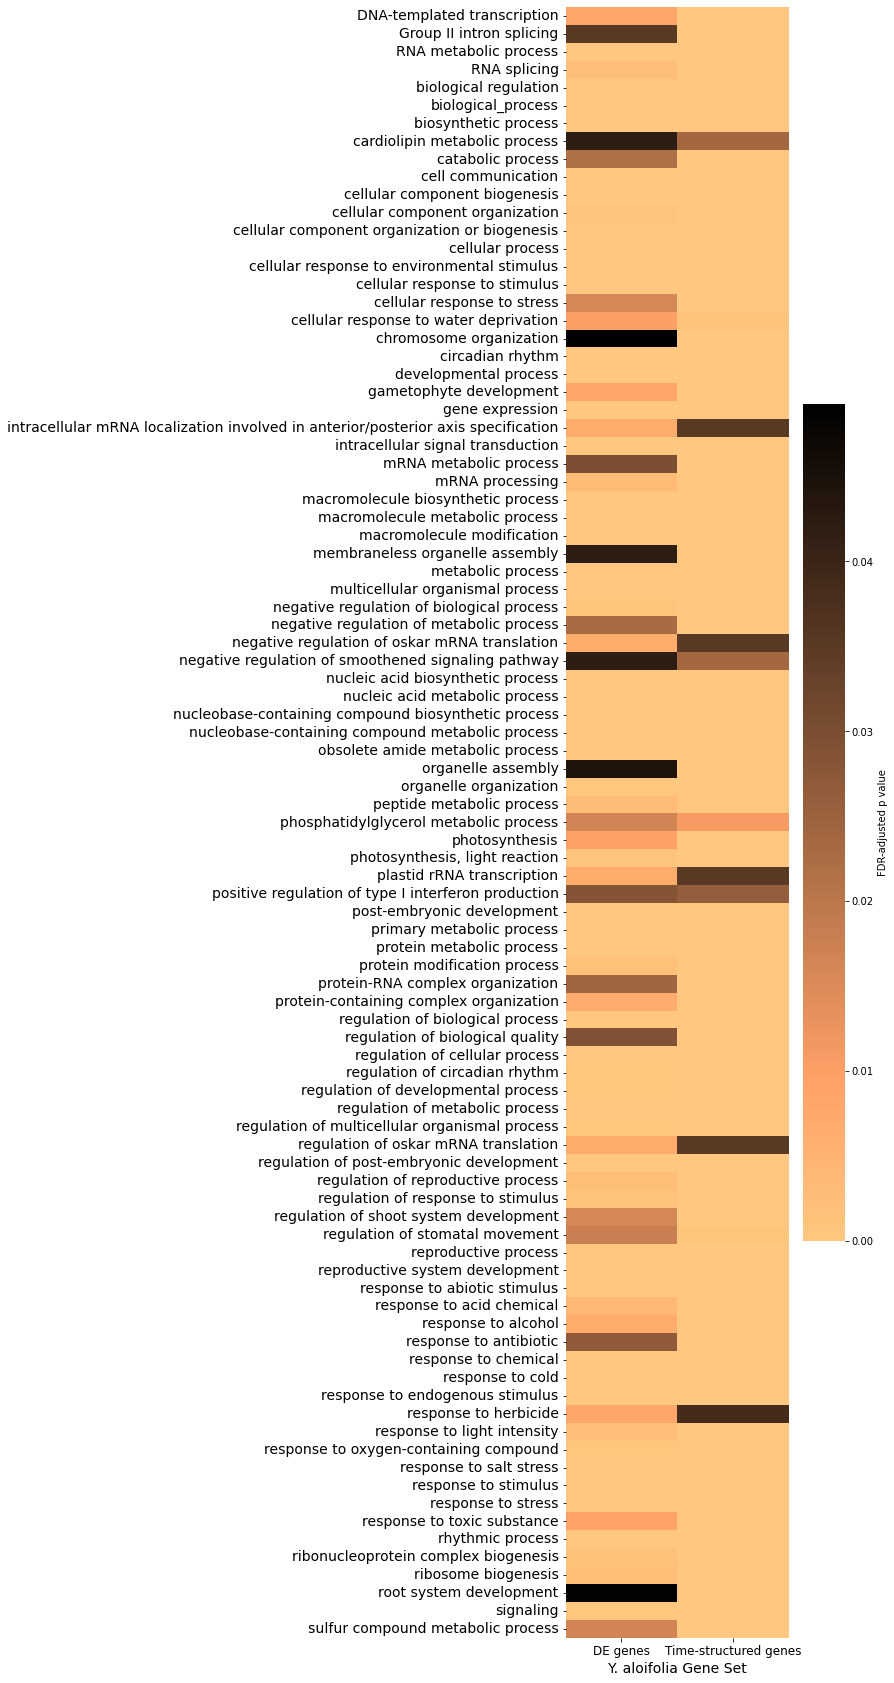

In [49]:
# make a figure: heatmap of Ya_DE & Ya_TS terms
plt.subplots(figsize=(5,30))
sns.heatmap(plot[["Ya_DE","Ya_TS"]].dropna(),cmap="copper_r",cbar_kws={"label":"FDR-adjusted p value","shrink":0.6})
plt.yticks(fontsize=14)
plt.ylabel("")
plt.xticks(ticks=np.arange(0.5,2.5,1),labels = ["DE genes","Time-structured genes"],fontsize=12)
plt.xlabel("Y. aloifolia Gene Set",fontsize=14)

plt.savefig("./Ya_maSigPro_GOenrich_heatmap.png",dpi=300,bbox_inches="tight")
plt.savefig("./Ya_maSigPro_GOenrich_heatmap.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./Ya_maSigPro_GOenrich_heatmap.svg",dpi=300,bbox_inches="tight")

In [50]:
len(plot[["YgC3+CAM_TS","YgCAM_TS","YgfacCAM_TS"]].dropna().index)

8

In [51]:
allyg = plot[["YgC3+CAM_TS","YgCAM_TS","YgfacCAM_TS"]].dropna()

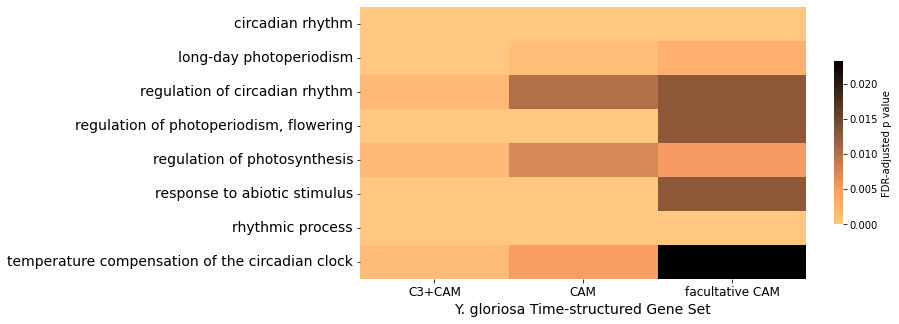

In [54]:
plt.subplots(figsize=(10,5))
sns.heatmap(allyg,cmap="copper_r",cbar_kws={"label":"FDR-adjusted p value","shrink":0.6})
plt.yticks(fontsize=14)
plt.ylabel("")
plt.xticks(ticks=np.arange(0.5,3.5,1),labels = ["C3+CAM","CAM","facultative CAM"],fontsize=12)
plt.xlabel("Y. gloriosa Time-structured Gene Set",fontsize=14)
plt.savefig("./Yg_maSigPro_GOterms_3way_revigo.png",dpi=300,bbox_inches="tight")
plt.savefig("./Yg_maSigPro_GOterms_3way_revigo.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./Yg_maSigPro_GOterms_3way_revigo.svg",dpi=300,bbox_inches="tight")

In [56]:
# make another figure with the terms that overlap in at least 2 Yg sets
yg2 = plot[["YgC3+CAM_TS","YgCAM_TS","YgfacCAM_TS"]].dropna(axis=0,thresh=2)

In [57]:
len(yg2.index)

47

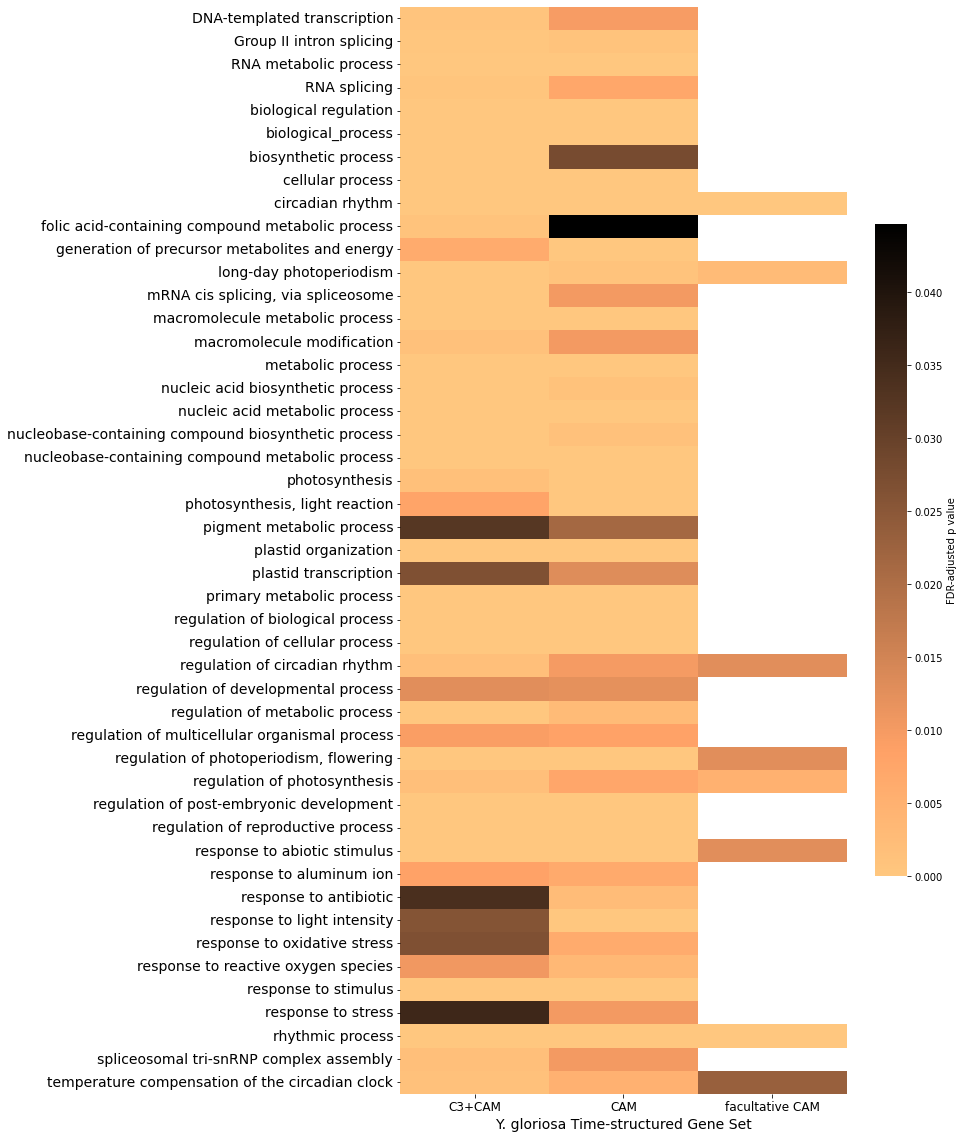

In [59]:
plt.subplots(figsize=(10,20))
sns.heatmap(yg2,cmap="copper_r",cbar_kws={"label":"FDR-adjusted p value","shrink":0.6})
plt.yticks(fontsize=14)
plt.ylabel("")
plt.xticks(ticks=np.arange(0.5,3.5,1),labels = ["C3+CAM","CAM","facultative CAM"],fontsize=12)
plt.xlabel("Y. gloriosa Time-structured Gene Set",fontsize=14)

plt.savefig("./Yg_2way_GOtermsRevigo_heatmap.png",dpi=300,bbox_inches="tight")
plt.savefig("./Yg_2way_GOtermsRevigo_heatmap.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./Yg_2way_GOtermsRevigo_heatmap.svg",dpi=300,bbox_inches="tight")

In [6]:
# 5/7/26: find GO terms (non-Revigo, so the full set) uniquely enriched in each physiotype's TS genes
ygres = res[res["regset"].isin(["YgCAM_TS","YgC3+CAM_TS","YgfacCAM_TS"])]

In [7]:
ygres.head()

,p.value,GO.term,p.adj,regset,Ontology,Term,Annotated,Significant,Expected,result1,Descr
0,0.000116,GO:0000244,0.010152,YgCAM_TS,BP,spliceosomal tri-snRNP complex assembly,15.0,5.0,0.52,0.00012,spliceosomal tri-snRNP complex assembly
1,0.000027,GO:0000302,0.003352,YgCAM_TS,BP,response to reactive oxygen species,285.0,25.0,9.96,2.7e-05,response to reactive oxygen species
2,0.000006,GO:0000373,0.000972,YgCAM_TS,BP,Group II intron splicing,39.0,9.0,1.36,6.2e-06,Group II intron splicing
3,0.000747,GO:0000387,0.043535,YgCAM_TS,BP,spliceosomal snRNP assembly,32.0,6.0,1.12,0.00075,spliceosomal snRNP assembly
4,0.000303,GO:0000395,0.022467,YgCAM_TS,BP,mRNA 5'-splice site recognition,18.0,5.0,0.63,0.00030,mRNA 5'-splice site recognition


In [28]:
# define a function: find unique GO terms (IDs) for a given regset
def get_unique_GOs(r,df=ygres):
    rdf = df[df["regset"]==r]
    ndf = df[df["regset"]!=r]
    gouniq = set(rdf["GO.term"]).difference(set(ndf["GO.term"]))
    return rdf[rdf["GO.term"].isin(list(gouniq))][["GO.term","Descr","p.adj","Annotated","Significant"]]

In [29]:
camgo = get_unique_GOs("YgCAM_TS")
len(camgo)

38

In [21]:
facgo = get_unique_GOs("YgfacCAM_TS")
len(facgo)

0

In [30]:
c3go = get_unique_GOs("YgC3+CAM_TS")
len(c3go)

35

In [31]:
camgo.to_csv("TS_YgCAM_unique_GOids.txt",sep="\t",header=True,index=False)
c3go.to_csv("TS_YgC3+CAM_unique_GOids.txt",sep="\t",header=True,index=False)

In [32]:
camgo["SigAnnRatio"] = camgo["Significant"]/camgo["Annotated"]
camgo.sort_values(by="SigAnnRatio",ascending=False,inplace=True)

In [33]:
c3go["SigAnnRatio"] = c3go["Significant"]/c3go["Annotated"]
c3go.sort_values(by="SigAnnRatio",ascending=False,inplace=True)

In [47]:
camgo.head()

,GO.term,Descr,p.adj,Annotated,Significant,SigAnnRatio
61,GO:0015746,citrate transport,4.921596e-03,3.0,3.0,1.000000
42,GO:0009769,"photosynthesis, light harvesting in photosyste...",2.791555e-02,5.0,3.0,0.600000
41,GO:0009768,"photosynthesis, light harvesting in photosystem I",2.875123e-10,31.0,14.0,0.451613
40,GO:0009765,"photosynthesis, light harvesting",2.344023e-23,86.0,34.0,0.395349
50,GO:0010100,negative regulation of photomorphogenesis,8.121951e-03,14.0,5.0,0.357143


In [55]:
# combine both datasets to get global min/max
vmin = min(camgo["p.adj"].min(), c3go["p.adj"].min())
vmax = max(camgo["p.adj"].max(), c3go["p.adj"].max())

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.cm.viridis_r

# map p-values to colors
cam_colors = cmap(norm(camgo["p.adj"].values))
c3_colors  = cmap(norm(c3go["p.adj"].values))

/tmp/ipykernel_183/870111430.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


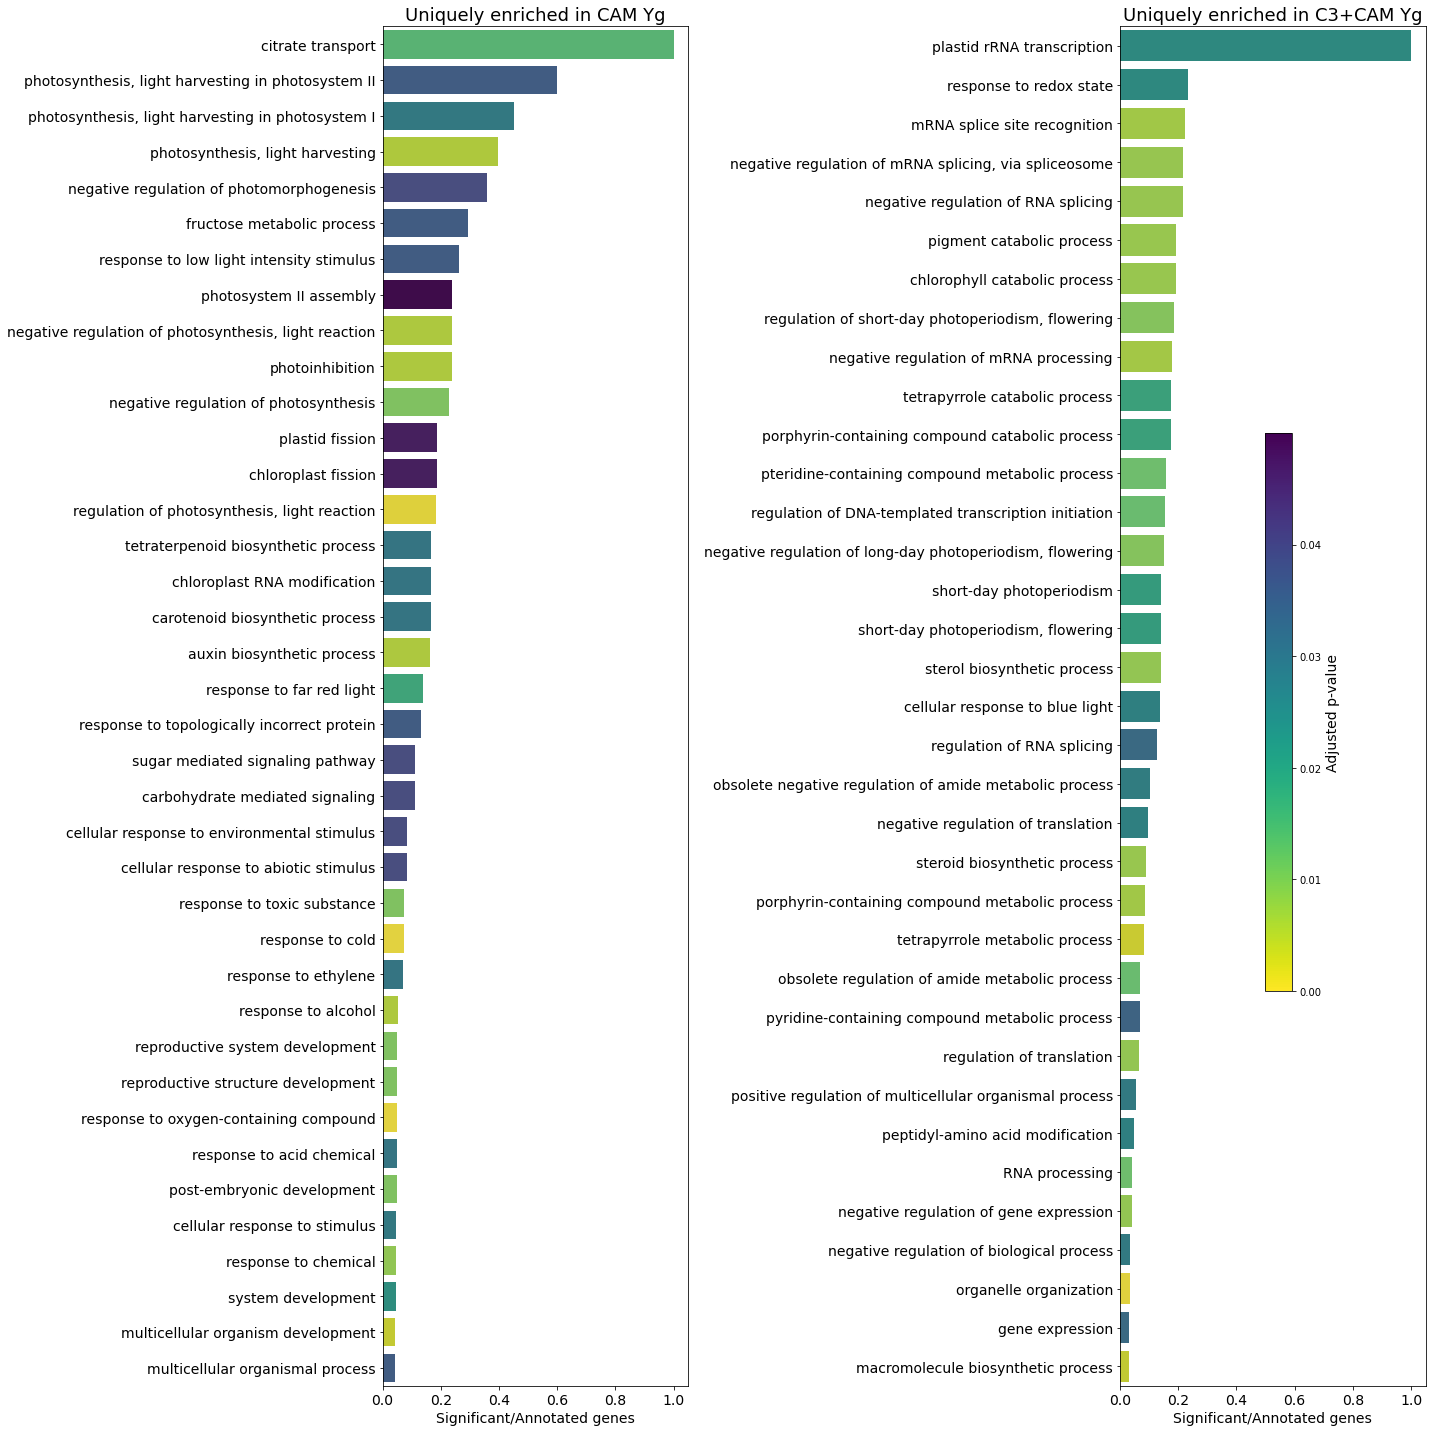

In [56]:
# plot Significant/Annotated ratio & color by p-value
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(20,20))

sns.barplot(ax=ax[0],data=camgo,x="SigAnnRatio",y="Descr",hue="p.adj",palette=cam_colors,dodge=False)
ax[0].set_title("Uniquely enriched in CAM Yg",fontsize=18)
ax[0].tick_params(which="both",labelsize=14)
ax[0].set_ylabel("")
ax[0].set_xlabel("Significant/Annotated genes",fontsize=14)
ax[0].get_legend().remove()
sns.barplot(ax=ax[1],data=c3go,x="SigAnnRatio",y="Descr",hue="p.adj",palette=c3_colors,dodge=False)
ax[1].set_title("Uniquely enriched in C3+CAM Yg",fontsize=18)
ax[1].tick_params(which="both",labelsize=14)
ax[1].set_ylabel("")
ax[1].set_xlabel("Significant/Annotated genes",fontsize=14)
ax[1].get_legend().remove()

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.025,
    pad=0.02
)

cbar.set_label("Adjusted p-value", fontsize=14)

fig.tight_layout()

plt.savefig("./TSgenes_YgCAM_YgC3+CAM_uniqueGO_barplots.png",dpi=300,bbox_inches="tight")
plt.savefig("./TSgenes_YgCAM_YgC3+CAM_uniqueGO_barplots.pdf",dpi=300,bbox_inches="tight")
plt.savefig("./TSgenes_YgCAM_YgC3+CAM_uniqueGO_barplots.svg",dpi=300,bbox_inches="tight")